# Tytuł projektu:
Ryby w wodzie

# Członkowie zespołu:
Mateusz Adamczyk
Mikołaj Batkiewicz
Aleksander Kaczyński

 Źródło zbioru danych:
 https://universe.roboflow.com/tbx/fishes-detection

# 1. Import bibliotek i wczytanie danych

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import random
import numpy as np

data_dir = Path("data") 
sets = ['train', 'valid', 'test']

fishes_data = {}

# Wczytanie danych
for s in sets:
    json_path = data_dir / s / "_annotations.coco.json"
    with open(json_path) as f:
        fishes_data[s] = json.load(f)

# Wyciągnięcie mapowania ID klasy na jej nazwę (korzystamy z folderu train jako bazy)
fish_categories = {ryba['id']: ryba['name'] for ryba in fishes_data['train']['categories']}

print(f"Pomyślnie wczytano dane z folderów: {sets}")

Pomyślnie wczytano dane z folderów: ['train', 'valid', 'test']


# Podstawowe statystyki i braki w danych - Liczba obrazów, Liczba unikalnych klas, Braki w anotacjach

In [2]:
# Zdefiniowanie klas, które nas interesują
target_classes = ['fish', 'jellyfish']

# Znalezienie ID tych klas w słowniku (zabezpieczenie wielkości liter)
target_fish__ids = {}
for fish_id, fish_name in fish_categories.items():
    if fish_name.lower() in [tc.lower() for tc in target_classes]:
        target_fish__ids[fish_name.lower()] = fish_id

print(f"Znalezione ID dla interesujących nas klas: {target_fish__ids}")

# --- 1. OGÓLNE STATYSTYKI ZBIORU ---
basic_stats = []
total_images = 0
total_missing_annotations = 0

for s in sets:
    images = fishes_data[s]['images']
    annotations = fishes_data[s]['annotations']
    categories = fishes_data[s]['categories']
    
    img_ids_with_fish = set([ann['image_id'] for ann in annotations])
    all_img_ids = set([img['id'] for img in images])
    missing_anns = len(all_img_ids - img_ids_with_fish)
    
    total_images += len(images)
    total_missing_annotations += missing_anns
    
    basic_stats.append({
        'Zbiór': s.upper(),
        'Liczba obrazów': len(images),
        'Liczba unikalnych klas': len(categories),
        'Liczba wszystkich bboxów': len(annotations),
        'Obrazy bez anotacji': missing_anns
    })

print("--- PODSTAWOWE STATYSTYKI ZBIORU (OGÓLNE) ---")
display(pd.DataFrame(basic_stats))

# --- 2. STATYSTYKI DLA KONKRETNYCH KLAS ---
for target_class in target_classes:
    if target_class not in target_fish__ids:
        print(f"\nUWAGA: Nie znaleziono klasy '{target_class}' w pliku JSON!")
        continue
        
    class_id = target_fish__ids[target_class]
    class_stats = []
    
    for s in sets:
        images = fishes_data[s]['images']
        annotations = fishes_data[s]['annotations']
        
        # Filtrujemy bbox'y tylko dla tej klasy
        class_bboxes = [ann for ann in annotations if ann['category_id'] == class_id]
        
        # Zliczamy unikalne obrazy, na których występuje ta klasa
        img_ids_with_class = set([ann['image_id'] for ann in class_bboxes])
        
        class_stats.append({
            'Zbiór': s.upper(),
            'Liczba obrazów z klasą': len(img_ids_with_class),
            'Liczba bboxów (wystąpień)': len(class_bboxes)
        })
        
    print(f"\n--- STATYSTYKI DLA KLASY: {target_class.upper()} ---")
    display(pd.DataFrame(class_stats))

Znalezione ID dla interesujących nas klas: {'fish': 15, 'jellyfish': 18}
--- PODSTAWOWE STATYSTYKI ZBIORU (OGÓLNE) ---


,Zbiór,Liczba obrazów,Liczba unikalnych klas,Liczba wszystkich bboxów,Obrazy bez anotacji
0,TRAIN,857,28,4246,0
1,VALID,267,28,1253,0
2,TEST,194,28,916,0



--- STATYSTYKI DLA KLASY: FISH ---


,Zbiór,Liczba obrazów z klasą,Liczba bboxów (wystąpień)
0,TRAIN,240,1961
1,VALID,63,459
2,TEST,30,249



--- STATYSTYKI DLA KLASY: JELLYFISH ---


,Zbiór,Liczba obrazów z klasą,Liczba bboxów (wystąpień)
0,TRAIN,32,385
1,VALID,9,155
2,TEST,11,154


# Analiza rozmiarów obrazów - Rozmiary obrazów (min, max, średni) (wykres punktowy)

--- STATYSTYKI ROZMIARÓW OBRAZÓW (Cały zbiór) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,606.421851,677.754173



--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: TRAIN) ---


,Szerokość,Wysokość
min,416.000000,416.00000
max,1024.000000,1024.00000
mean,625.362894,696.38273



--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: VALID) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,598.292135,675.235955



--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: TEST) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,533.938144,598.927835


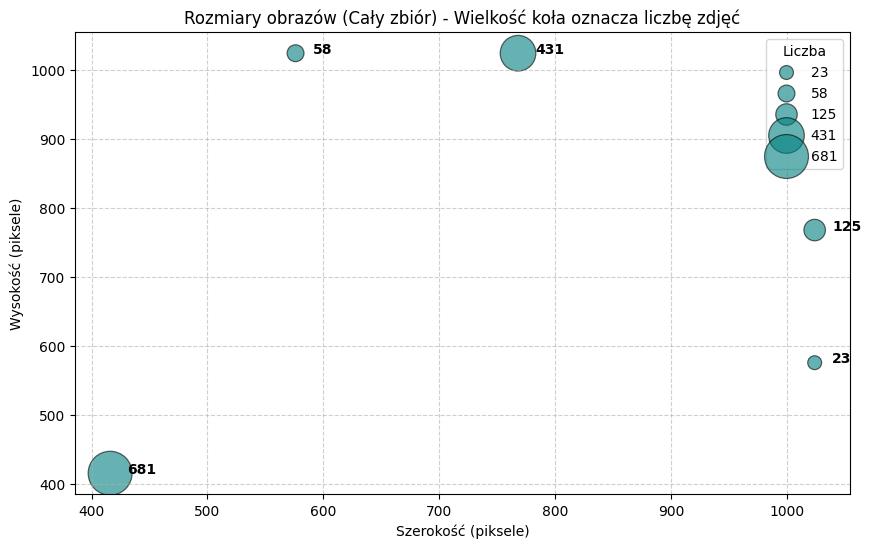

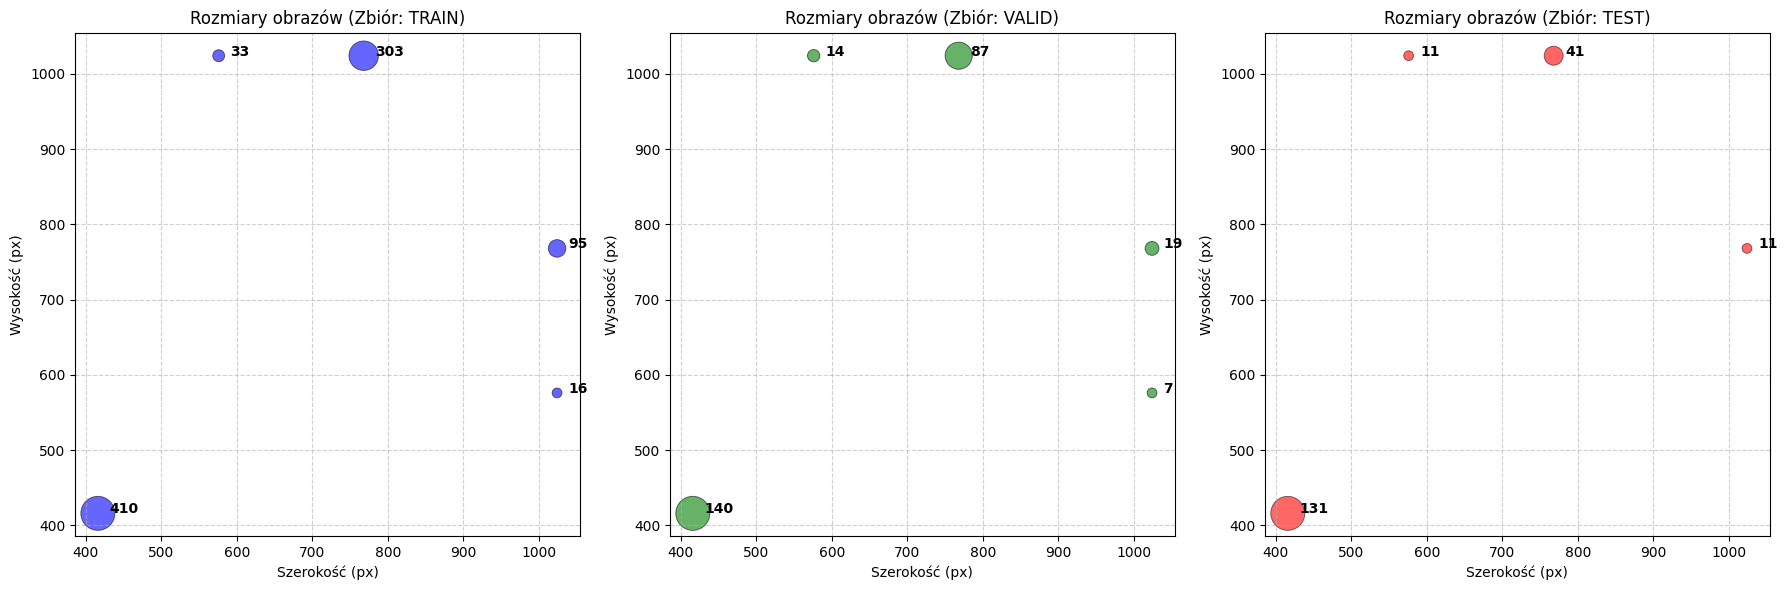


--- ANALIZA ROZMIARÓW OBRAZÓW TYLKO DLA WYBRANYCH KLAS ---


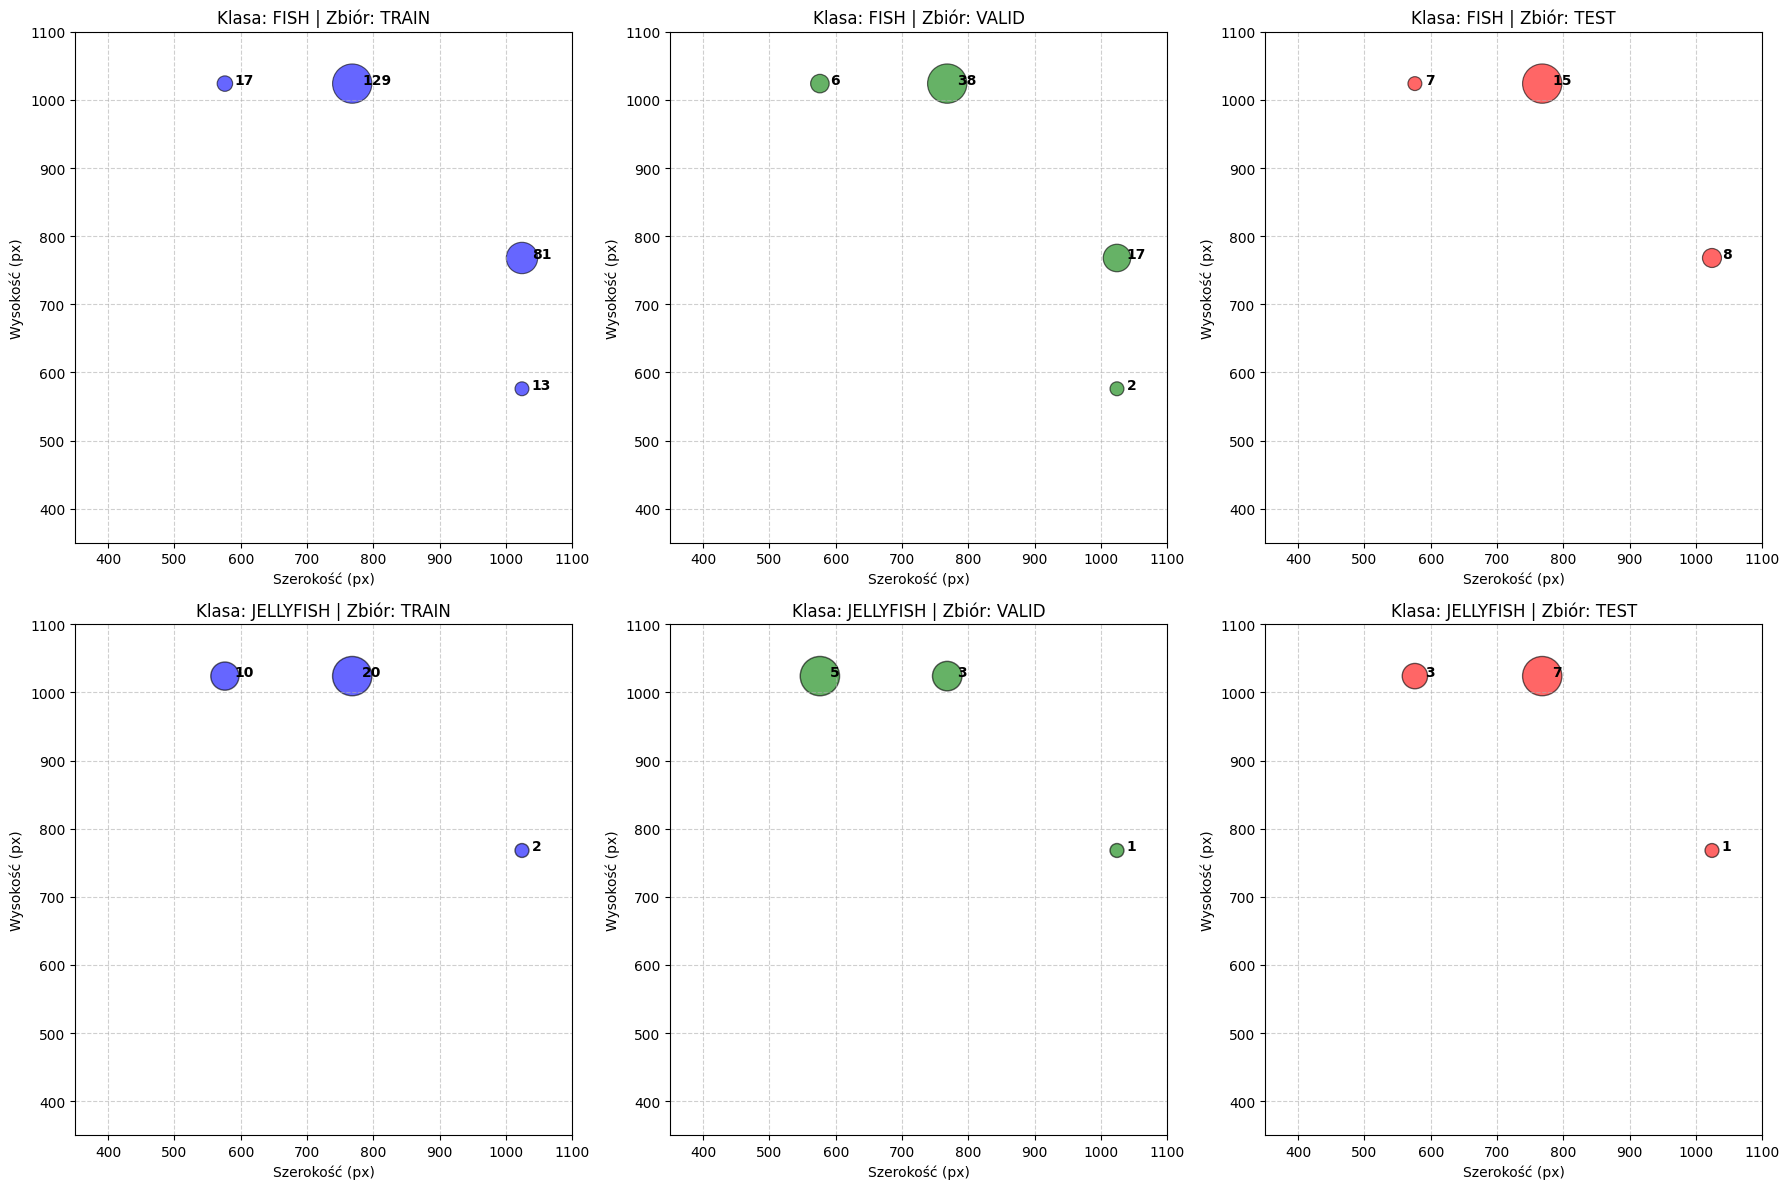

In [3]:
image_sizes = []

for s in sets:
    for img in fishes_data[s]['images']:
        image_sizes.append({
            'Zbiór': s,
            'Szerokość': img['width'],
            'Wysokość': img['height']
        })

df_sizes = pd.DataFrame(image_sizes)

# --- 1. TABELE ZE STATYSTYKAMI (CAŁY ZBIÓR) ---
print("--- STATYSTYKI ROZMIARÓW OBRAZÓW (Cały zbiór) ---")
display(df_sizes[['Szerokość', 'Wysokość']].describe().loc[['min', 'max', 'mean']])

for s in sets:
    print(f"\n--- STATYSTYKI ROZMIARÓW OBRAZÓW (Zbiór: {s.upper()}) ---")
    df_split = df_sizes[df_sizes['Zbiór'] == s]
    display(df_split[['Szerokość', 'Wysokość']].describe().loc[['min', 'max', 'mean']])

# --- 2. PRZYGOTOWANIE DANYCH DO WYKRESÓW Z LICZNOŚCIĄ ---
# Grupowanie, aby zliczyć ile jest zdjęć o danej szerokości i wysokości
df_counts_all = df_sizes.groupby(['Szerokość', 'Wysokość']).size().reset_index(name='Liczba')
df_counts_split = df_sizes.groupby(['Zbiór', 'Szerokość', 'Wysokość']).size().reset_index(name='Liczba')

# --- 3. WYKRES DLA CAŁEGO ZBIORU ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_counts_all, x='Szerokość', y='Wysokość', size='Liczba', sizes=(100, 1000), alpha=0.6, color='teal', edgecolor='black')
plt.title('Rozmiary obrazów (Cały zbiór) - Wielkość koła oznacza liczbę zdjęć')
plt.xlabel('Szerokość (piksele)')
plt.ylabel('Wysokość (piksele)')
plt.grid(True, linestyle='--', alpha=0.6)

# Dodawanie tekstowych etykiet z liczbą zdjęć obok punktów
for i in range(df_counts_all.shape[0]):
    plt.text(df_counts_all['Szerokość'].iloc[i] + 15, df_counts_all['Wysokość'].iloc[i], 
             str(df_counts_all['Liczba'].iloc[i]), color='black', weight='bold', fontsize=10)
plt.show()

# --- 4. WYKRESY DLA POSZCZEGÓLNYCH ZBIORÓW ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'train': 'blue', 'valid': 'green', 'test': 'red'}

for i, s in enumerate(sets):
    df_subset = df_counts_split[df_counts_split['Zbiór'] == s].reset_index(drop=True)
    sns.scatterplot(ax=axes[i], data=df_subset, x='Szerokość', y='Wysokość', size='Liczba', sizes=(50, 600), 
                    alpha=0.6, color=colors[s], edgecolor='black', legend=False)
    axes[i].set_title(f'Rozmiary obrazów (Zbiór: {s.upper()})')
    axes[i].set_xlabel('Szerokość (px)')
    axes[i].set_ylabel('Wysokość (px)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Dodawanie etykiet tekstowych
    for j in range(df_subset.shape[0]):
        axes[i].text(df_subset['Szerokość'].iloc[j] + 15, df_subset['Wysokość'].iloc[j], 
                     str(df_subset['Liczba'].iloc[j]), color='black', weight='bold', fontsize=10)

plt.tight_layout()
plt.show()


# =====================================================================
# --- 5. DODATEK: WYKRESY TYLKO DLA WYBRANYCH KLAS (FISH, JELLYFISH) ---
# =====================================================================

print("\n--- ANALIZA ROZMIARÓW OBRAZÓW TYLKO DLA WYBRANYCH KLAS ---")

class_image_sizes = []

for s in sets:
    images = fishes_data[s]['images']
    annotations = fishes_data[s]['annotations']
    
    # Tworzymy słownik dla szybkiego dostępu do wymiarów obrazu po jego ID
    img_dict = {img['id']: {'width': img['width'], 'height': img['height']} for img in images}
    
    for target_class in target_classes:  # Zmienna target_classes pochodzi z Komórki 2
        if target_class not in target_fish__ids:
            continue
            
        class_id = target_fish__ids[target_class]
        
        # Znajdź unikalne ID obrazów, które mają adnotację tej klasy
        img_ids_with_class = set([ann['image_id'] for ann in annotations if ann['category_id'] == class_id])
        
        for img_id in img_ids_with_class:
            class_image_sizes.append({
                'Klasa': target_class,
                'Zbiór': s,
                'Szerokość': img_dict[img_id]['width'],
                'Wysokość': img_dict[img_id]['height']
            })

df_class_sizes = pd.DataFrame(class_image_sizes)

if df_class_sizes.empty:
    print("Brak danych do wygenerowania wykresów dla podanych klas.")
else:
    # Przygotowanie danych do wykresów bąbelkowych dla poszczególnych klas
    df_counts_class = df_class_sizes.groupby(['Klasa', 'Zbiór', 'Szerokość', 'Wysokość']).size().reset_index(name='Liczba')
    
    # Rysowanie wykresów (Siatka 2x3: wiersze to klasy, kolumny to zbiory)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for row_idx, target_class in enumerate(target_classes):
        for col_idx, s in enumerate(sets):
            ax = axes[row_idx, col_idx]
            
            df_subset = df_counts_class[(df_counts_class['Klasa'] == target_class) & (df_counts_class['Zbiór'] == s)].reset_index(drop=True)
            
            if not df_subset.empty:
                sns.scatterplot(ax=ax, data=df_subset, x='Szerokość', y='Wysokość', size='Liczba', 
                                sizes=(100, 800), alpha=0.6, color=colors[s], edgecolor='black', legend=False)
                
                # Dodawanie etykiet tekstowych
                for i in range(df_subset.shape[0]):
                    ax.text(df_subset['Szerokość'].iloc[i] + 15, df_subset['Wysokość'].iloc[i], 
                            str(df_subset['Liczba'].iloc[i]), color='black', weight='bold', fontsize=10)
            
            ax.set_title(f"Klasa: {target_class.upper()} | Zbiór: {s.upper()}")
            ax.set_xlabel('Szerokość (px)')
            ax.set_ylabel('Wysokość (px)')
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # Ujednolicenie osi, żeby łatwiej było porównywać wzrokowo (dopasowane do Twoich obrazów max 1024)
            ax.set_xlim(350, 1100)
            ax.set_ylim(350, 1100)

    plt.tight_layout()
    plt.show()

# Detekcja - Balans klas i statystyki BBoxów - Balans klas, Liczba masek/boxów na klasę, Średnia powierzchnia bounding boxów, Średnia liczba bboxów na klasę

--- STATYSTYKI DETEKCJI (CAŁOŚĆ) ---
Średnia powierzchnia bounding boxa ogółem: 20202.27 pikseli kwadratowych
Średnia liczba bboxów przypadająca na jedną klasę: 237.59

--- ŚREDNIA POWIERZCHNIA BBOXA W POSZCZEGÓLNYCH ZBIORACH ---
Zbiór TRAIN: 20629.51 pikseli kwadratowych
Zbiór VALID: 20341.75 pikseli kwadratowych
Zbiór TEST: 18031.00 pikseli kwadratowych




/tmp/ipykernel_3268/985012103.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boxes_per_class.values, y=boxes_per_class.index, palette="viridis")


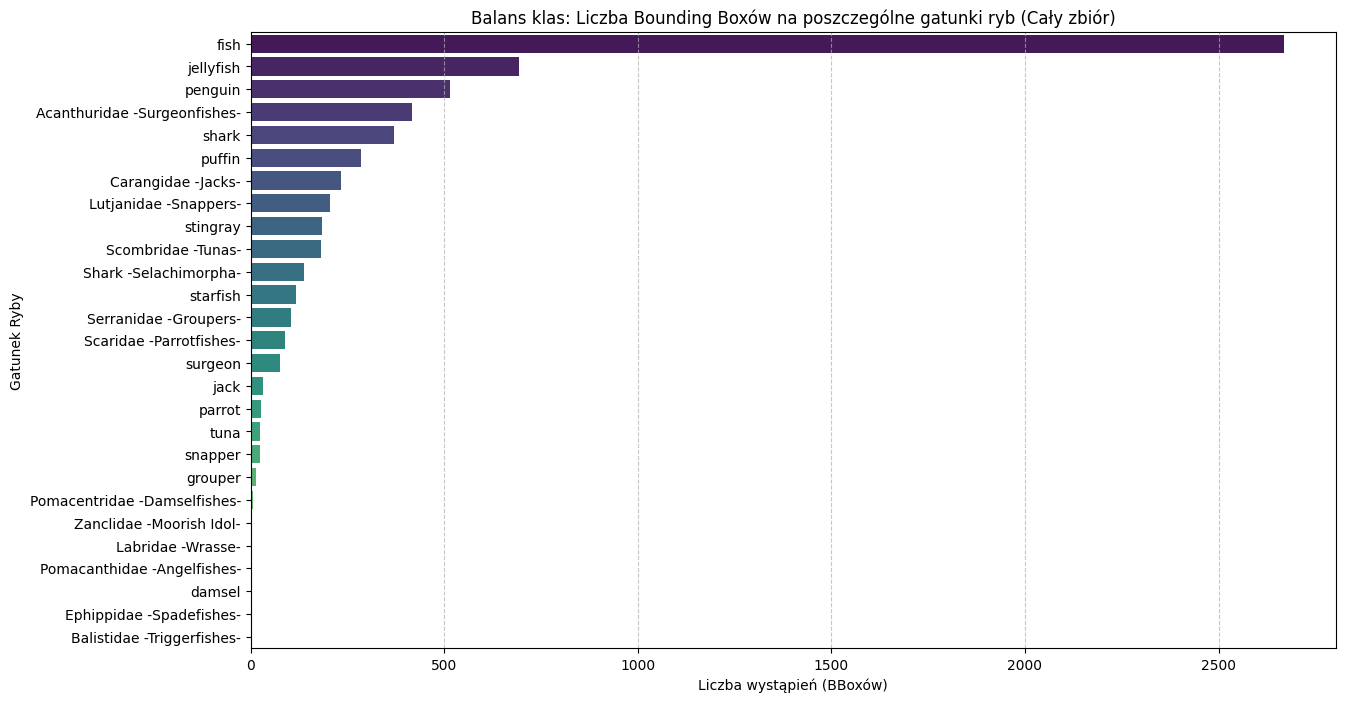

Tabela podsumowująca liczbę bboxów na klasę:


,Liczba BBoxów
Nazwa_Gatunku,
fish,2669
jellyfish,694
penguin,516
Acanthuridae -Surgeonfishes-,416
shark,371
puffin,284
Carangidae -Jacks-,234
Lutjanidae -Snappers-,206
stingray,184


In [4]:
all_annotations = []
for s in sets:
    for ann in fishes_data[s]['annotations']:
        ann_copy = ann.copy()
        ann_copy['Zbiór'] = s  # Dodajemy informację o zbiorze do każdego bboxa
        all_annotations.append(ann_copy)

df_bboxes = pd.DataFrame(all_annotations)
# Dodanie nazwy klasy na podstawie category_id
df_bboxes['Nazwa_Gatunku'] = df_bboxes['category_id'].map(fish_categories)

# --- 1. OBLICZENIA DLA CAŁEGO ZBIORU ---
average_bbox_area = df_bboxes['area'].mean()
boxes_per_class = df_bboxes['Nazwa_Gatunku'].value_counts()
average_boxes_per_class = boxes_per_class.mean()

print("--- STATYSTYKI DETEKCJI (CAŁOŚĆ) ---")
print(f"Średnia powierzchnia bounding boxa ogółem: {average_bbox_area:.2f} pikseli kwadratowych")
print(f"Średnia liczba bboxów przypadająca na jedną klasę: {average_boxes_per_class:.2f}\n")

# --- 2. ŚREDNIA POWIERZCHNIA BBOXA (Z PODZIAŁEM NA ZBIORY) ---
print("--- ŚREDNIA POWIERZCHNIA BBOXA W POSZCZEGÓLNYCH ZBIORACH ---")
for s in sets:
    split_area = df_bboxes[df_bboxes['Zbiór'] == s]['area'].mean()
    print(f"Zbiór {s.upper()}: {split_area:.2f} pikseli kwadratowych")
print("\n")

# --- 3. WYKRES BALANSU KLAS ---
plt.figure(figsize=(14, 8))
sns.barplot(x=boxes_per_class.values, y=boxes_per_class.index, palette="viridis")
plt.title('Balans klas: Liczba Bounding Boxów na poszczególne gatunki ryb (Cały zbiór)')
plt.xlabel('Liczba wystąpień (BBoxów)')
plt.ylabel('Gatunek Ryby')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Tabela podsumowująca liczbę bboxów na klasę:")
display(pd.DataFrame(boxes_per_class).rename(columns={'count': 'Liczba BBoxów'}))

# Wizualizacja danych z etykietami - Wyświetl przykładowe obrazy wraz z bounding boxami

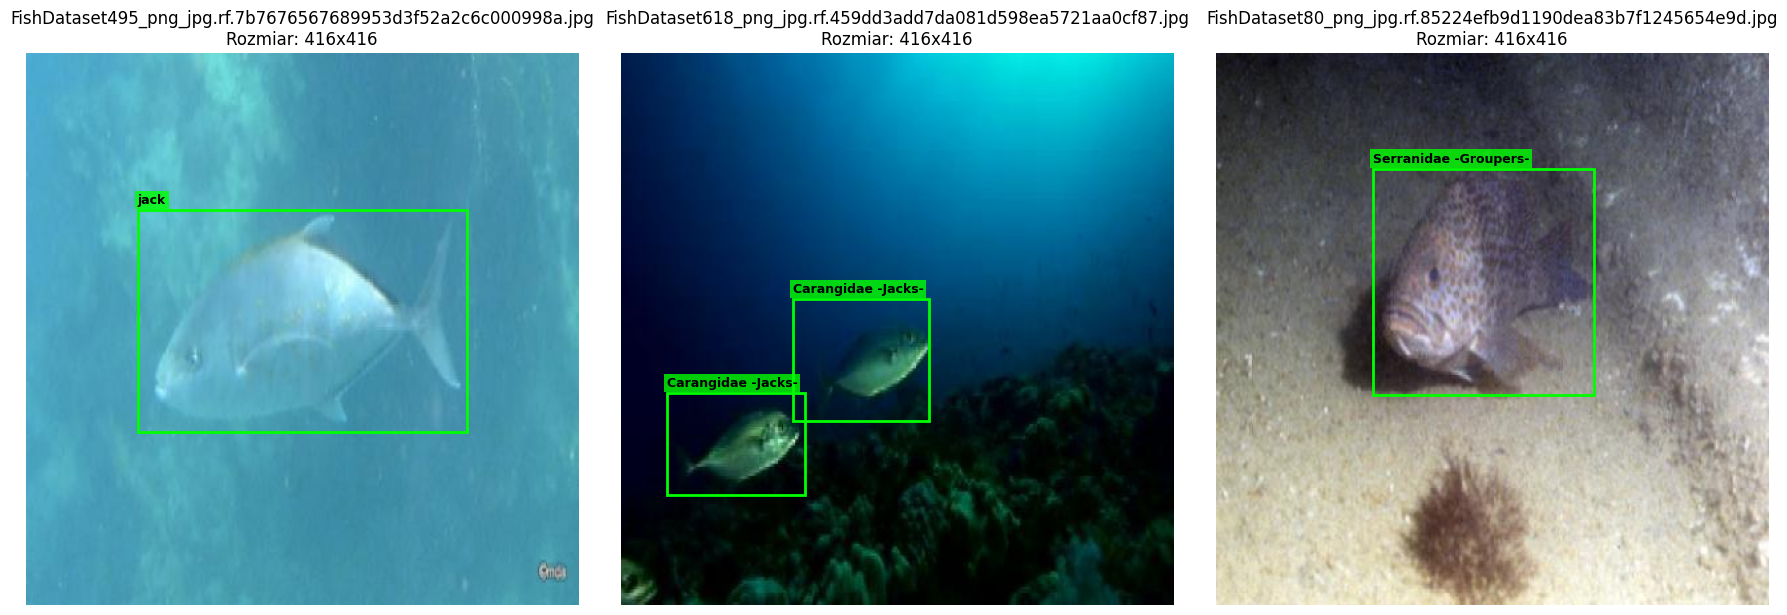

In [5]:
def imshow_fishes(set_name='train', num_images=3):
    data = fishes_data[set_name]
    images_list = data['images']
    anns_list = data['annotations']
    
    # Wybieramy losowe obrazy
    sample_imgs = random.sample(images_list, num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(18, 6))
    if num_images == 1: axes = [axes]

    for ax, img_info in zip(axes, sample_imgs):
        img_path = data_dir / set_name / img_info['file_name']
        
        # Wczytanie i konwersja kolorów
        image = cv2.imread(str(img_path))
        if image is None:
            ax.set_title("Błąd wczytywania")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax.imshow(image)
        ax.axis('off')
        
        # Wymiary rzeczywiste wrzucone w tytuł dla potwierdzenia
        ax.set_title(f"{img_info['file_name']}\nRozmiar: {img_info['width']}x{img_info['height']}")

        # Filtrowanie bboxów dla tego konkretnego zdjęcia
        fish_bboxes = [ann for ann in anns_list if ann['image_id'] == img_info['id']]

        # Rysowanie Bounding Boxów
        for ann in fish_bboxes:
            x, y, w, h = ann['bbox']
            # Rysujemy ramkę
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            
            # Podpis gatunku
            species_name = fish_categories[ann['category_id']]
            ax.text(x, max(0, y - 5), species_name, color='black', fontsize=9, weight='bold',
                    bbox=dict(facecolor='#00FF00', alpha=0.8, edgecolor='none', pad=2))

    plt.tight_layout()
    plt.show()

# Uruchomienie funkcji - wyświetlamy 3 losowe ryby ze zbioru testowego
imshow_fishes(set_name='test', num_images=3)

# import + transformacje (augmentacja)
Zainstalowanie biblioteki Albumentations
Format ramek (BBox):
Zmiana ramki z formatu COCO [x_min, y_min, szerokość, wysokość] na Pascal VOC [x_min, y_min, x_max, y_max] (Konwersja w Dataloader)
Wielkość zdjęcia 416x416
Wykorzystanie Albumentations - Letterboxing (LongestMaxSize + PadIfNeeded) -> ryby nie będą jak w tych memach spłaszczone

In [43]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np

# Zdefiniowanie stałych
BATCH_SIZE = 8 # możliwa zmiana na 16,  ilość obrazów jaką sieć neuronowa przetwarza w jednym cyklu, zanim zaktualizuje swoje wewnętrzne wagi
IMG_SIZE = 416
TARGET_CLASSES = ['fish', 'jellyfish']

# Transformacje dla zbioru TRENINGOWEGO (z augmentacjami)
train_transform = A.Compose([
    # Skalowanie z zachowaniem proporcji
    A.LongestMaxSize(max_size=IMG_SIZE),
    # Dodanie czarnych pasków, by obraz był idealnym kwadratem 416x416
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),
    # Augmentacje
    A.HorizontalFlip(p=0.6), # 60% szans na odbicie lustrzane
    # NOWE: Przesunięcie, Skalowanie i Obrót (max 15 stopni). 0.0625 to dokładnie 1/16. Jak obraz ma bok 416 px to przesuniecie w dowolnym kierunku (pionowo/poziomo) o 26 pikseli (416*0.0625=26)
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=25,border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0], p=0.5),
    # Zmiana kolorów wody (odcienie, nasycenie). Z RGB na HSV (Hue, Saturation, Value) -> losowa modyfikacja parametrów i powrót do RGB
    # Hue to kolor -180->180, Saturation to nasycenie 0-255, Value to jasność 0-255
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.55),# Jasność i Kontrast
    # Symulacja ruchu ryby/rozmycia
    A.MotionBlur(blur_limit=5, p=0.2), #jeździmy jądrem (kernel) rozmiar rozmycia, nieparzysta liczba, min 3, 3,5,7
    # Normalizacja standardowa dla PyTorch i konwersja na Tensor
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),# średnie wartości kolorów odpowiednio dla RGB, nowy_piksel = (piksel / 255.0 - mean) / std
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

# Transformacje dla zbioru WALIDACYJNEGO I TESTOWEGO (BEZ augmentacji, tylko zmiana rozmiaru)
val_test_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),#jednolite tło i czarne paski RGB(0,0,0)
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

print("Zdefiniowano transformacje i augmentacje.")

Zdefiniowano transformacje i augmentacje.


/tmp/ipykernel_3268/2752040901.py:18: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),
/home/mateu/msi_projekt/venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_3268/2752040901.py:22: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=25,border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0], p=0.5),
/tmp/ipykernel_3268/2752040901.py:37: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0]),#jednolite tło i czarne paski RGB(0,0,0)


# Dodanie klasy MyDataset i collate_fn
Zbiór danych zwraca parę. Obraz jako tensor oraz target (słownik z ramkami i etykietami)
Implementacja 3 metod:
__init__ (inicjalizacja ścieżek i transformacji)
__len__ (liczba próbek)
__getitem__ (pobranie pojedynczej próbki po indeksie)
Stworzenie klasy MyDataset, która będzie wczytywać tylko zdjęcia zawierające "fish" lub "jellyfish", nadając im numery odpowiednio 1 i 2 (numer 0 to tło w pytorch)

In [44]:
class MyDataset(Dataset):
    def __init__(self, data_dir, set_name, json_data, target_classes, transform=None):
        self.data_dir = data_dir / set_name
        self.transform = transform
        self.json_data = json_data
        
        # Słownik zamieniający nazwy klas na ID: np. {'fish': 1, 'jellyfish': 2}
        self.class_name_to_id = {name: idx + 1 for idx, name in enumerate(target_classes)}
        
        # Szukamy oryginalnych ID z pliku JSON dla interesujących nas klas
        valid_fish_ids = [fish['id'] for fish in json_data['categories'] if fish['name'].lower() in target_classes]
        
        self.images = []
        self.annotations = []
        img_dict = {img['id']: img for img in json_data['images']}
        
        # Zgrupowanie adnotacji po obrazku i odrzucenie tych bez naszych ryb
        # Jeśli ramka należy do naszej wybranej klasy (ryba lub meduza), dodajemy ją do słownika ann_by_img
        from collections import defaultdict
        ann_by_img = defaultdict(list)
        for ann in json_data['annotations']:
            if ann['category_id'] in valid_fish_ids:
                ann_by_img[ann['image_id']].append(ann)
                
        for img_id, anns in ann_by_img.items():
            self.images.append(img_dict[img_id])
            self.annotations.append(anns)

    def __len__(self): # ilosc zdjec w zbiorze
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.data_dir / img_info['file_name']
        
        # Wczytanie obrazu
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Przetworzenie Bounding Boxów (Z formatu COCO na Pascal VOC)
        bboxes = []
        labels = []
        for ann in self.annotations[idx]:
            x_min, y_min, w, h = ann['bbox']
            x_max = x_min + w
            y_max = y_min + h
            
            # Zabezpieczenie przed błędami w danych (ramki poza ekranem)
            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(img_info['width'], x_max), min(img_info['height'], y_max)
            
            if x_max > x_min and y_max > y_min:
                bboxes.append([x_min, y_min, x_max, y_max])
                # Znajdź nazwę oryginalną i przypisz nasze nowe ID (1 lub 2)
                orig_fish_id = ann['category_id']
                orig_fish_name = next(c['name'] for c in self.json_data['categories'] if c['id'] == orig_fish_id).lower()
                labels.append(self.class_name_to_id[orig_fish_name])

        target = {}
        # Aplikowanie transformacji z Albumentations
        if self.transform:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
            image = transformed['image']
            bboxes = transformed['bboxes']
            labels = transformed['class_labels']

        # Konwersja do formatu, którego oczekuje PyTorch
        target['boxes'] = torch.as_tensor(bboxes, dtype=torch.float32)
        target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
        target['image_id'] = torch.tensor([img_info['id']])
        
        # Jeśli augmentacja usunęła wszystkie ramki (bardzo rzadkie przy letterboxingu)
        if len(bboxes) == 0:
            target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.zeros((0,), dtype=torch.int64)

        return image, target

# Funkcja pomocnicza: sieci Object Detection zwracają różną ilość ramek dla różnych zdjęć, 
# więc domyślny loader by zwariował (wymagałby tej samej liczby). Ta funkcja temu zapobiega.
def custom_collate_fn(batch):
    return tuple(zip(*batch))

print("Klasa MyDataset i funkcja collate_fn gotowe.")

Klasa MyDataset i funkcja collate_fn gotowe.


# Tworzenie Dataloaderów
Inicjacja naszych zbiorów i pakowanie w obiekty DataLoader (grupowanie w paczki -> batche)

In [41]:
# Inicjalizacja zbiorów danych
train_dataset = MyDataset(data_dir, 'train', fishes_data['train'], TARGET_CLASSES, transform=train_transform)
valid_dataset = MyDataset(data_dir, 'valid', fishes_data['valid'], TARGET_CLASSES, transform=val_test_transform)
test_dataset = MyDataset(data_dir, 'test', fishes_data['test'], TARGET_CLASSES, transform=val_test_transform)

# Tworzenie Dataloaderów
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate_fn)

print(f"Ilość paczek (batchy) treningowych: {len(train_loader)}")
print(f"Ilość paczek walidacyjnych: {len(valid_loader)}")
print(f"Ilość paczek testowych: {len(test_loader)}")

Ilość paczek (batchy) treningowych: 34
Ilość paczek walidacyjnych: 9
Ilość paczek testowych: 6


# Pokazanie obrazów z i bez augmentacji -> imshow

/tmp/ipykernel_3268/2545226430.py:53: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0])
/tmp/ipykernel_3268/2545226430.py:60: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  ("4. Przesunięcie i Obrót (ShiftScaleRotate)", [A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0], p=1.0)]),


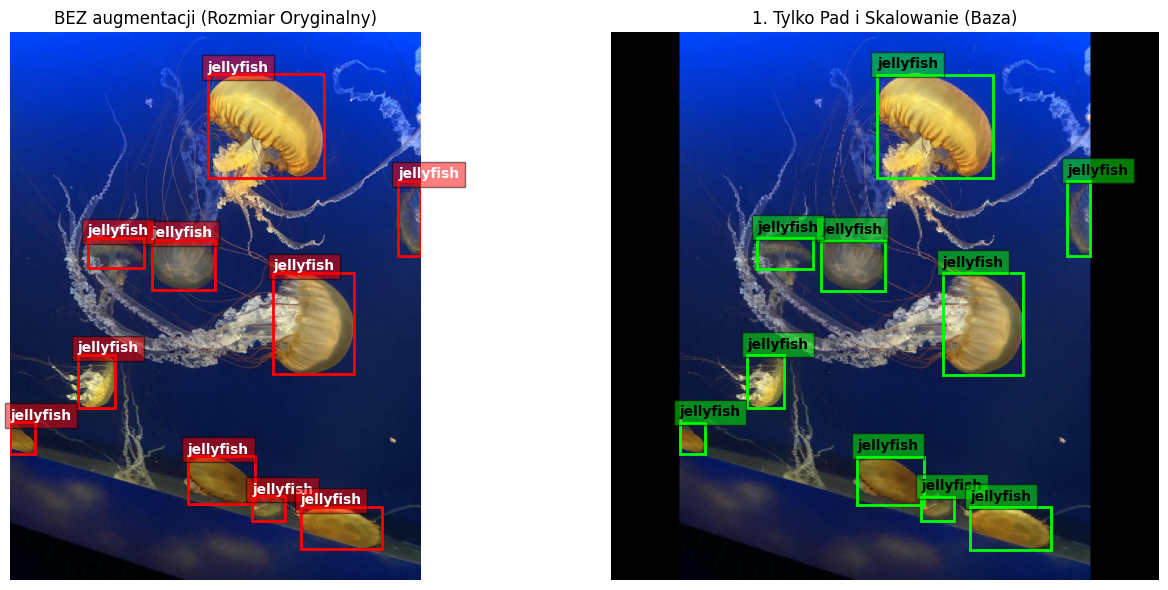

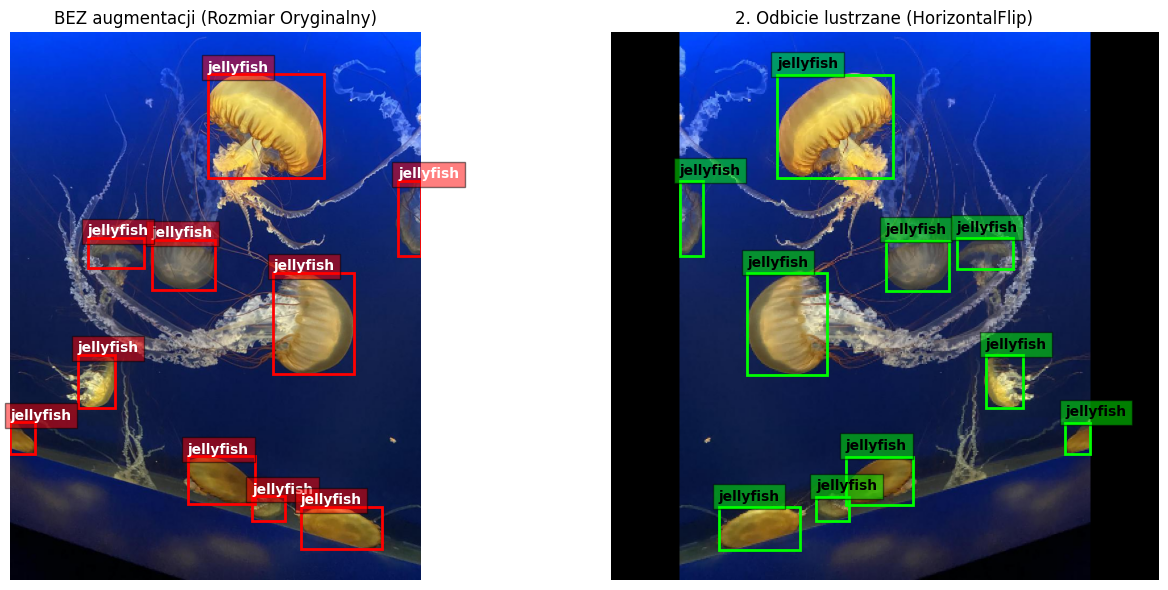

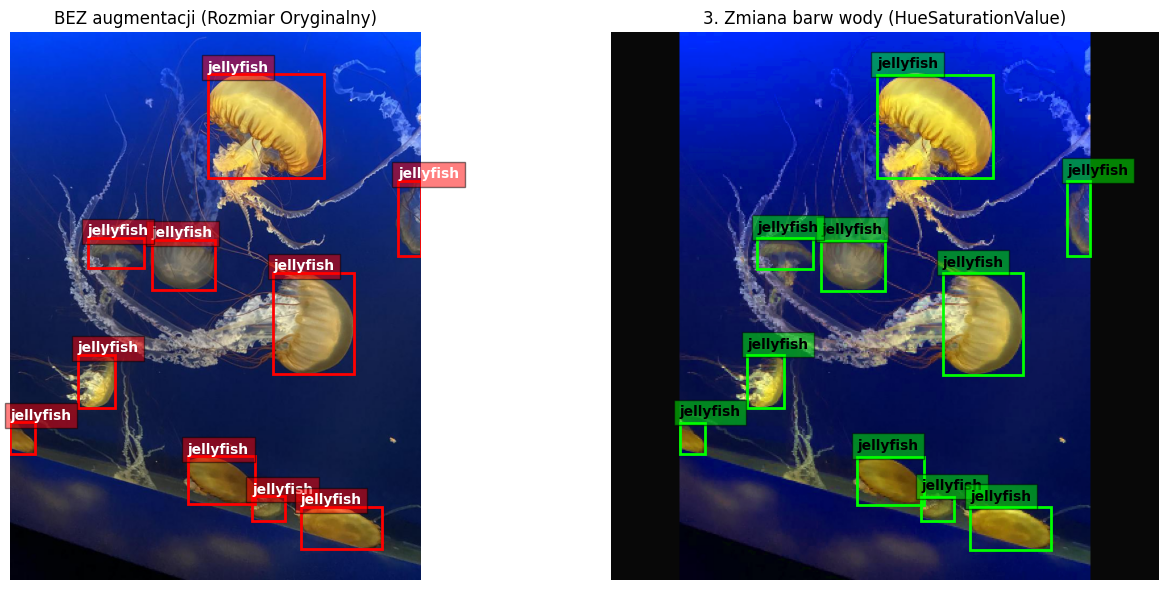

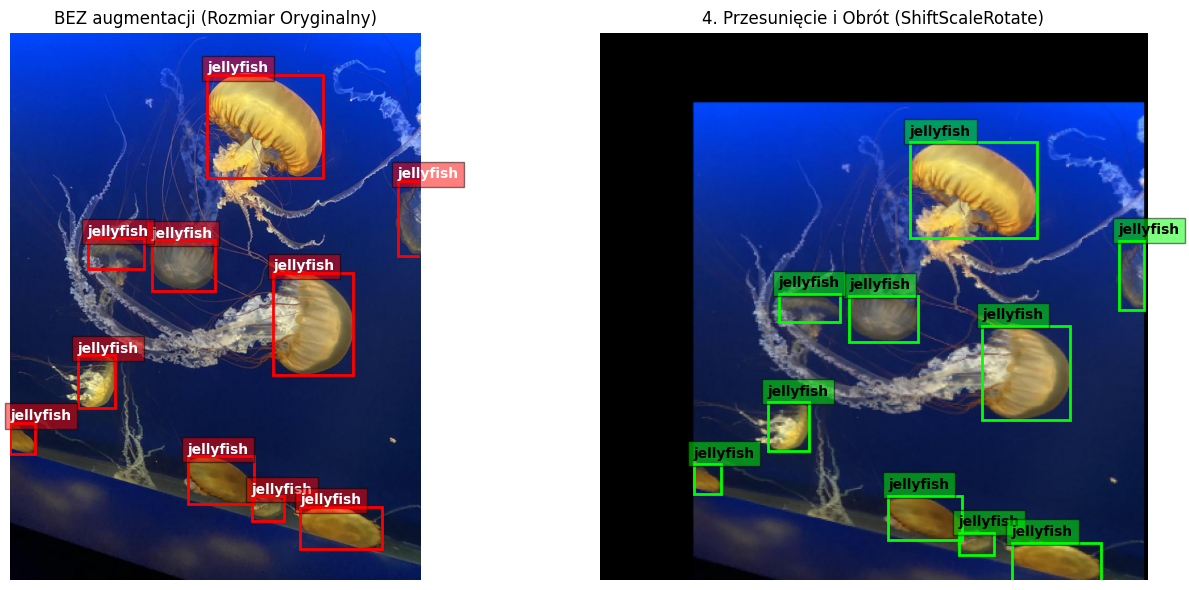

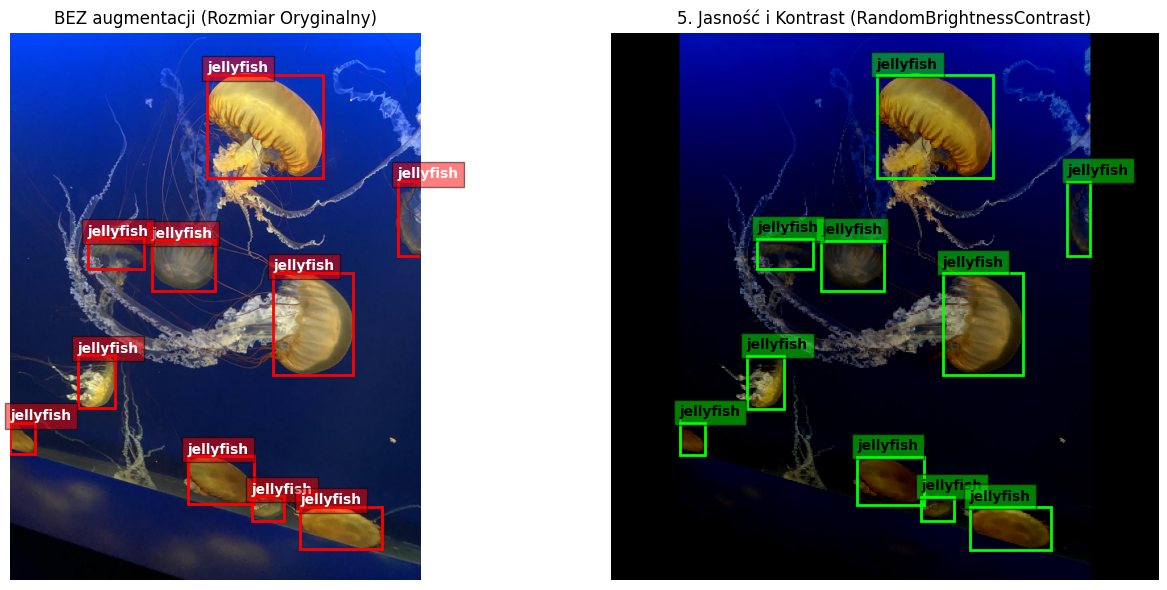

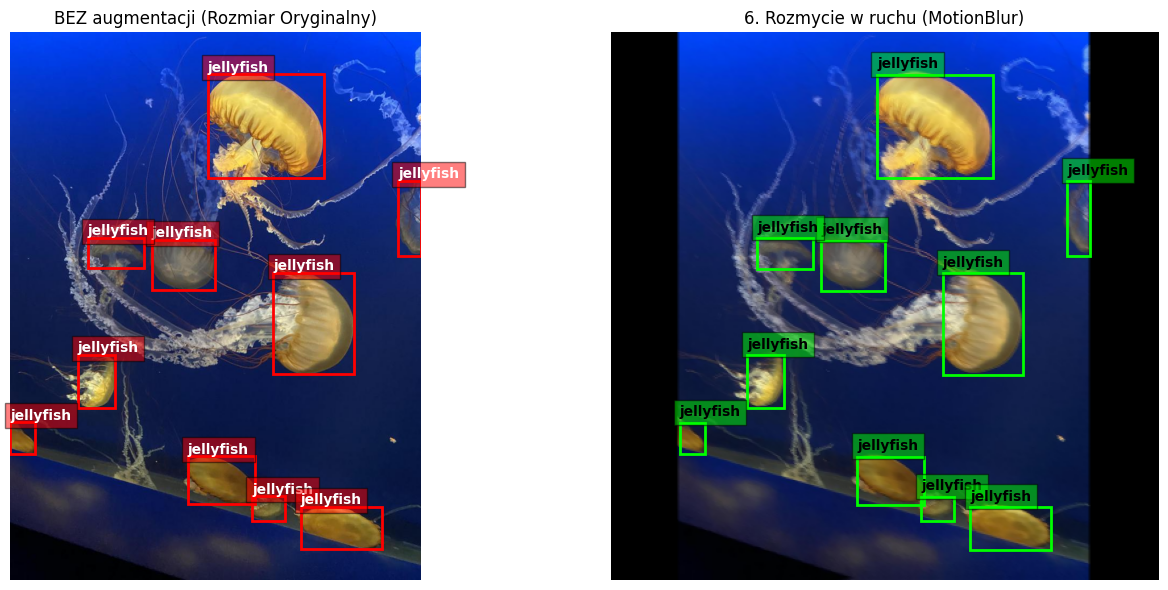

In [ ]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import albumentations as A
import cv2
def imshow_comparison(dataset_no_aug, dataset_aug, idx=0, aug_title="Z augmentacją"):
    """
    Funkcja pobiera obrazek i bounding boxy, a następnie rysuje wersję przed i po augmentacji.
    """
    # Zastrzegamy odwrotne mapowanie ID -> Nazwa
    id_to_class = {v: k for k, v in dataset_no_aug.class_name_to_id.items()}
    
    # Wczytanie z obu zbiorów
    img_no_aug, target_no_aug = dataset_no_aug[idx]
    img_aug, target_aug = dataset_aug[idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Obraz BEZ augmentacji
    axes[0].imshow(img_no_aug)
    axes[0].set_title('BEZ augmentacji (Rozmiar Oryginalny)')
    axes[0].axis('off')
    for box, label in zip(target_no_aug['boxes'], target_no_aug['labels']):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x_min, max(0, y_min-5), id_to_class[label.item()], color='white', weight='bold', bbox=dict(facecolor='red', alpha=0.5))

    # 2. Obraz Z augmentacją
    axes[1].imshow(img_aug)
    axes[1].set_title(aug_title) # Dynamiczny tytuł
    axes[1].axis('off')
    for box, label in zip(target_aug['boxes'], target_aug['labels']):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='#00FF00', facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x_min, max(0, y_min-5), id_to_class[label.item()], color='black', weight='bold', bbox=dict(facecolor='#00FF00', alpha=0.5))

    plt.tight_layout()
    plt.show()

# Definiujemy transformację WIZUALNĄ (wymuszamy 100% szans na nałożenie, żeby to zaprezentować -> Ustawiamy p=1.0
# wyłączamy Normalize, żeby kolory nie zwariowały na wykresie)

# Zbiór bez augmentacji (referencyjny)
vis_dataset_no_aug = MyDataset(data_dir, 'train', fishes_data['train'], TARGET_CLASSES, transform=None)

# Wybieramy jedno zdjęcie do testów (zmień to ID, żeby sprawdzić inne ryby)
TEST_IMAGE_IDX = 0

# Baza, która musi być włączona zawsze (skalowanie i paski)
base_aug = [
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0])
]
# Lista pojedynczych augmentacji
augmentations_to_test = [
    ("1. Tylko Pad i Skalowanie (Baza)", []),
    ("2. Odbicie lustrzane (HorizontalFlip)", [A.HorizontalFlip(p=1.0)]),
    ("3. Zmiana barw wody (HueSaturationValue)", [A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1.0)]),
    ("4. Przesunięcie i Obrót (ShiftScaleRotate)", [A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=25, border_mode=cv2.BORDER_CONSTANT, value=[0, 0, 0], p=1.0)]),
    ("5. Jasność i Kontrast (RandomBrightnessContrast)", [A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)]),
    ("6. Rozmycie w ruchu (MotionBlur)", [A.MotionBlur(blur_limit=5, p=1.0)])
]

# Generowanie kolejnych obrazków
for title, aug_step in augmentations_to_test:
    # Łączymy bazę z aktualnie testowaną augmentacją
    temp_transform = A.Compose(base_aug + aug_step, bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))
    temp_dataset = MyDataset(data_dir, 'train', fishes_data['train'], TARGET_CLASSES, transform=temp_transform)
    
    imshow_comparison(vis_dataset_no_aug, temp_dataset, idx=TEST_IMAGE_IDX, aug_title=title)

Po padingu widzimy czarne ramki na zdjęciach - letterboxing, co oznacza, że zostały dobrze skompresowane do idealnego kwadratu 416x416 bez scalania ryb. Bounding boxy "wędrują" po nałożeniu efektu lustra - dzięki temu że użyliśmy Albumentations

# 4. Definicja modelu sieci neuronowej

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# zdefiniowanie klasy modelu
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Wczytujemy przeuczony model Faster R-CNN z backbone'em ResNet50
        # Używamy wag domyślnych (DEFAULT), czyli modelu trenowanego na gigantycznym zbiorze COCO
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT') #wypróbuj fasterrcnn_mobilenet_v3_large_fpn, fasterrcnn_resnet50_fpn (bazowo był)

        # Pobieramy liczbę wejść do ostatniej warstwy klasyfikującej
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features

        # Podmieniamy domyślną głowę modelu na nową, która zwróci naszą liczbę klas
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    def forward(self, images, targets=None):
        # W trybie treningu (gdy targets nie są None), model zwróci słownik z obliczonymi stratami (loss)
        # W trybie ewaluacji (testu), model zwróci predykcje (bboxy, klasy, pewność)
        return self.model(images, targets)

# Nasze klasy to: 0 - Tło, 1 - Fish, 2 - Jellyfish
NUM_CLASSES = 3
net = Net(NUM_CLASSES)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
net.to(device)
print(f"Model załadowany i przeniesiony na urządzenie: {device}")

# Zdefiniowanie Optymalizatora
# Zbieramy parametry modelu, które będą aktualizowane podczas treningu
params = [p for p in net.parameters() if p.requires_grad]

# Używamy optymalizatora SGD (Stochastic Gradient Descent) - to standard przy Faster R-CNN
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Zdefiniowanie funkcji celu (Criterion)
criterion = "Funkcja celu jest obliczana wewnętrznie przez model Faster R-CNN."

print("Optymalizator gotowy. Model jest przygotowany do treningu!")

Model załadowany i przeniesiony na urządzenie: cuda
Optymalizator gotowy. Model jest przygotowany do treningu!


# Krok 5. Trenowanie modelu (Pętla ucząca)

In [ ]:
import time

EPOCHS = 5

print(f"Rozpoczynamy trenowanie na urządzeniu: {device}")
history_loss = []
for epoch in range(EPOCHS):
    net.train() 
    epoch_loss = 0
    start_time = time.time()
    for batch_idx, (images, targets) in enumerate(train_loader):
        
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # wyzerogradientów przed kolejnym krokiem
        optimizer.zero_grad()
        loss_dict = net(images, targets)
        # Sumujemy typy strat (błąd klasyfikacji, błąd ułożenia ramki itp.)
        losses = sum(loss for loss in loss_dict.values())
        # obliczanie gradientów
        losses.backward()
        # krok optymalizacji(aktualizacja wag modelu)
        optimizer.step()
        epoch_loss += losses.item()

        # Wyświetlanie statystyk co 10 batchy
        if batch_idx % 10 == 0:
            print(f"Epoka: {epoch+1}/{EPOCHS} | Batch: {batch_idx}/{len(train_loader)} | Loss: {losses.item():.4f}")
    end_time = time.time()
    avg_epoch_loss = epoch_loss / len(train_loader)
    history_loss.append(avg_epoch_loss)
    print(f"--- Koniec Epoki {epoch+1} ---")
    print(f"Średni Loss: {avg_epoch_loss:.4f} | Czas trwania: {end_time - start_time:.2f} s\n")
torch.save(net.state_dict(), 'fishes_rcnn_v1_sgd_005.pth')
print("Trening zakończony! Wagi modelu zostały zapisane do pliku 'fishes_rcnn_v1_sgd_005.pth'.")#Zmieniaj nazwe pliku dla kazdego eksperymentu

Rozpoczynamy trenowanie na urządzeniu: cuda


KeyboardInterrupt: 

# Narysowanie krzywej zbieżności

In [11]:
import matplotlib.pyplot as plt

# Rysowanie krzywej zbieżności funkcji straty
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history_loss, marker='o', linestyle='-', linewidth=2, color='blue')

plt.title('Krzywa zbieżności funkcji straty (Loss Curve)', fontsize=14, weight='bold')
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Wartość funkcji straty (Loss)', fontsize=12)
plt.xticks(range(1, EPOCHS + 1)) # Wymuszenie wyświetlania tylko pełnych numerów epok
plt.grid(True, linestyle='--', alpha=0.7)

# Wyświetlenie wykresu
plt.show()

NameError: name 'EPOCHS' is not defined

<Figure size 1000x600 with 0 Axes>

# 6. Ewaluacja modelu

Model został pomyślnie wczytany i przygotowany do testów.


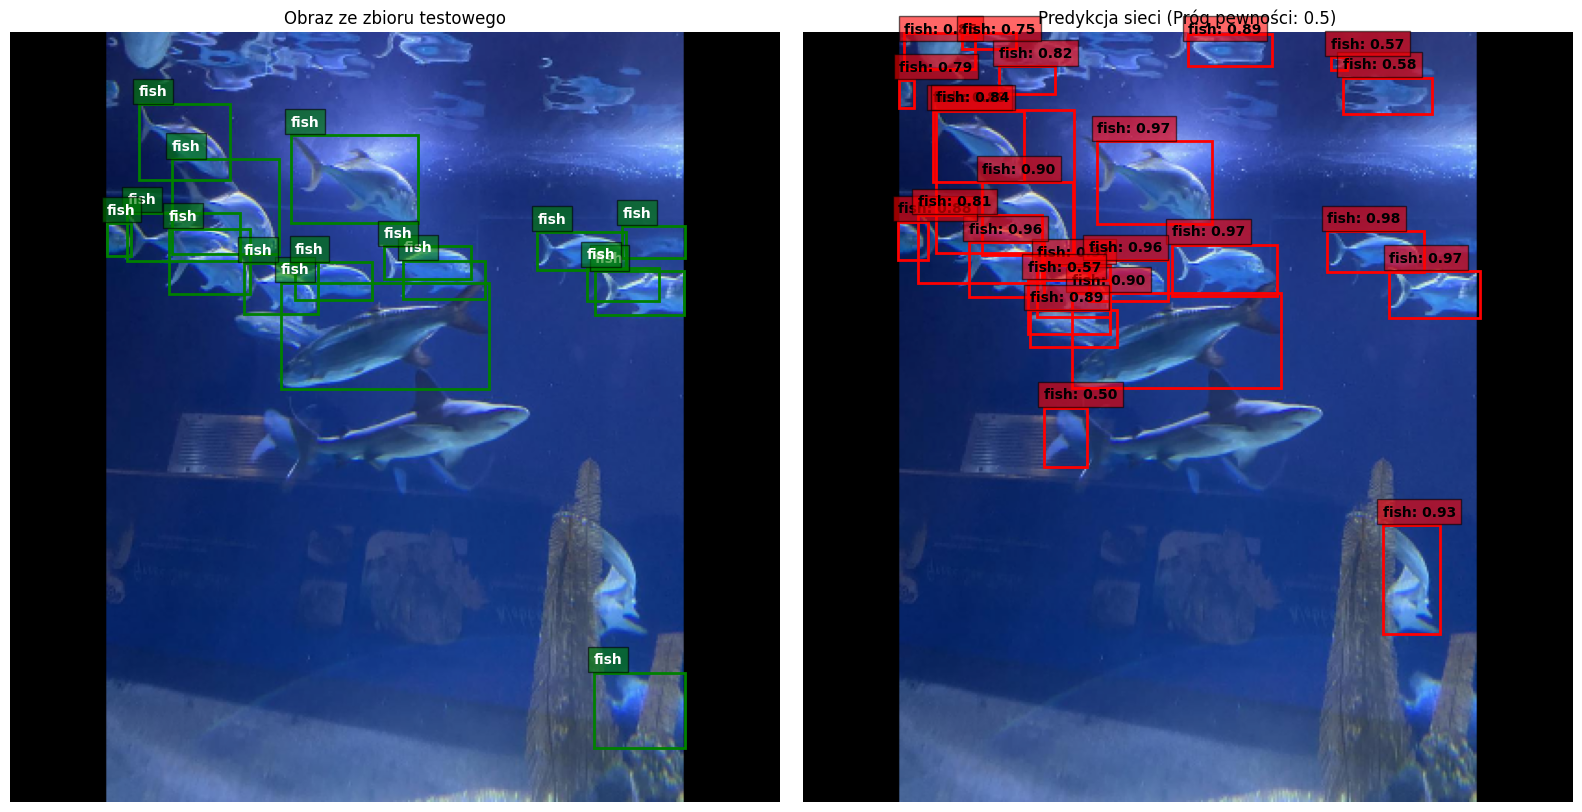

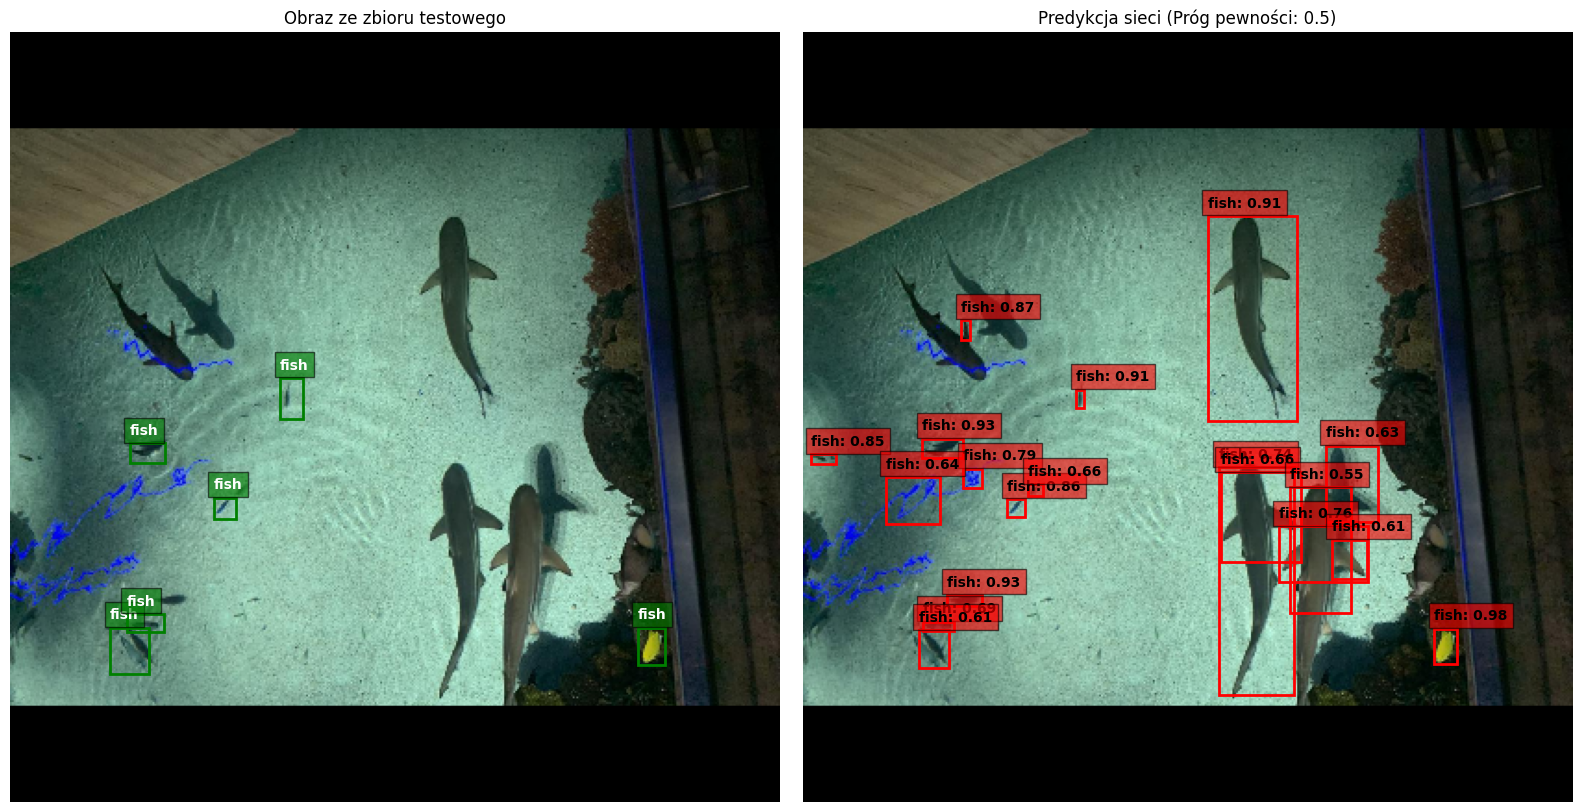

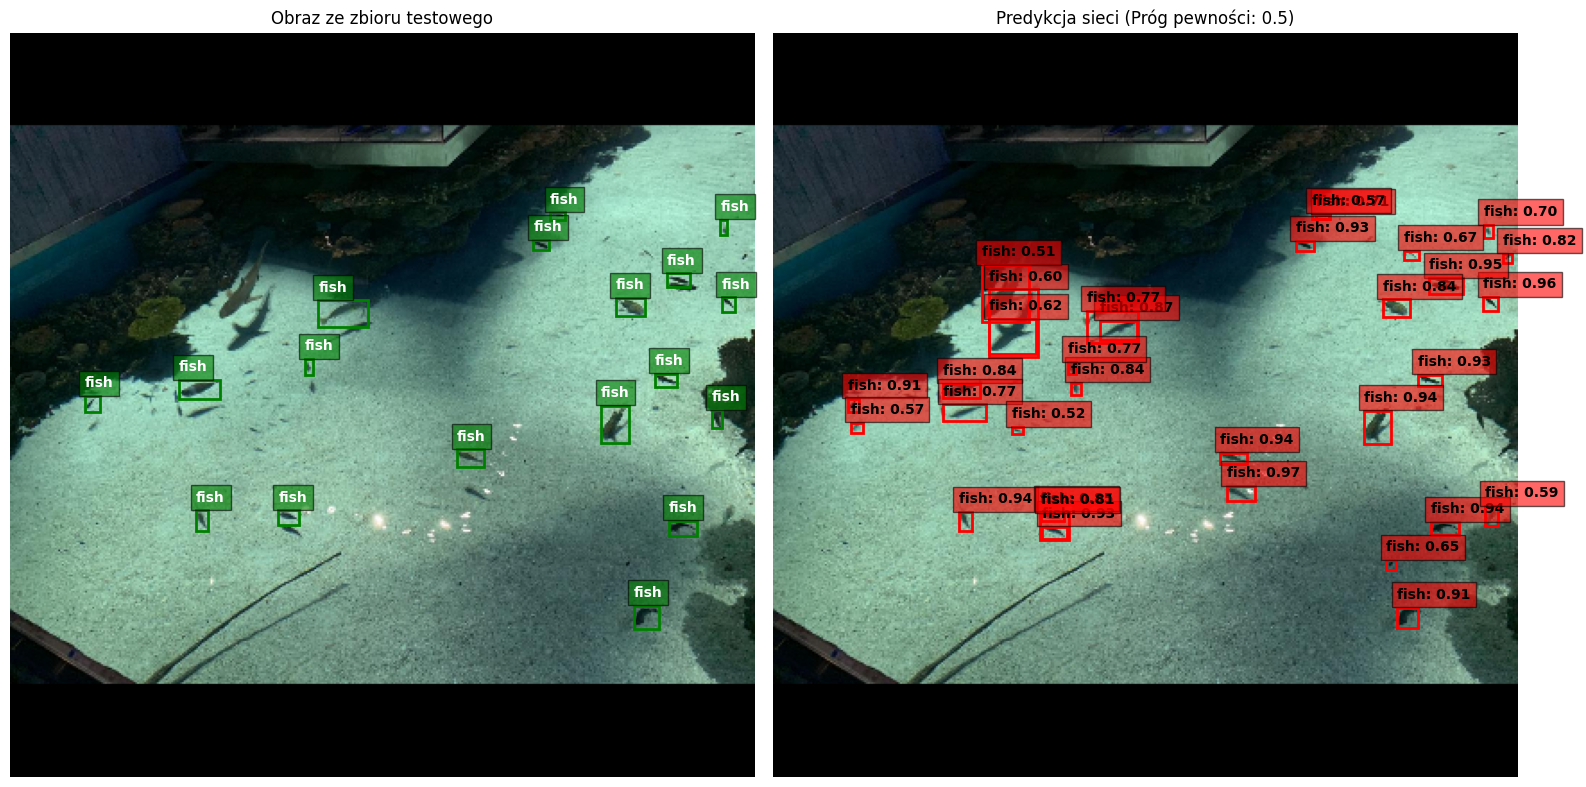

In [12]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import cv2

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
net = Net(num_classes=3)

net.load_state_dict(torch.load('fishes_rcnn_v1_sgd_005.pth', map_location=device))
net.to(device)
net.eval() # PRZEŁĄCZENIE W TRYB EWALUACJI (Wyłącza m.in. Dropout i Batch Normalization)

print("Model został pomyślnie wczytany i przygotowany do testów.")

def evaluate_visual(dataset, num_samples=3, confidence_threshold=0.5):
    id_to_class = {1: 'fish', 2: 'jellyfish'}
    
    # wybór losowych indeksów ze zbioru testowego
    indices = random.sample(range(len(dataset)), num_samples)
    
    for idx in indices:
        # Pobieramy obraz i prawdziwe etykiety
        image_tensor, target = dataset[idx]
        
        # Przygotowanie obrazu do wyświetlenia (odwrócenie normalizacji dla ładnych kolorów)
        img_show = image_tensor.permute(1, 2, 0).cpu().numpy()
        # Od-normalizowanie obrazu (przybliżone wartości dla standardowego ImageNet)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1)
        
        # Predykcja sieci
        with torch.no_grad(): # Wyłączamy zapamiętywanie gradientów (oszczędność pamięci)
            prediction = net([image_tensor.to(device)])[0]
            
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        # Obraz ze zbioru testowego
        axes[0].imshow(img_show)
        axes[0].set_title("Obraz ze zbioru testowego")
        axes[0].axis('off')
        
        for box, label in zip(target['boxes'], target['labels']):
            x1, y1, x2, y2 = box.numpy()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='green', facecolor='none')
            axes[0].add_patch(rect)
            axes[0].text(x1, max(0, y1-5), id_to_class[label.item()], color='white', weight='bold', bbox=dict(facecolor='green', alpha=0.6))
            
        #PANEL PRAWY: Predykcja Modelu
        axes[1].imshow(img_show)
        axes[1].set_title(f"Predykcja sieci (Próg pewności: {confidence_threshold})")
        axes[1].axis('off')
        
        pred_boxes = prediction['boxes'].cpu().numpy()
        pred_labels = prediction['labels'].cpu().numpy()
        pred_scores = prediction['scores'].cpu().numpy()
        
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            if score >= confidence_threshold: # Wyświetlamy tylko pewne detekcje
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
                axes[1].add_patch(rect)
                
                label_text = f"{id_to_class[label]}: {score:.2f}"
                axes[1].text(x1, max(0, y1-5), label_text, color='black', weight='bold', bbox=dict(facecolor='red', alpha=0.6))
                
        plt.tight_layout()
        plt.show()

# Wywołujemy funkcję dla zbioru testowego
evaluate_visual(test_dataset, num_samples=3, confidence_threshold=0.5)

Obliczanie metryk dla klas i całości
Przejście przez procesor testowy - test_loader i porównanie dopasowania ramek za pomocą wbudowanej funkcji box_iou i wyliczy Precyzję (Precision), Czułość (Recall) oraz Dokładność (F1-score) ogółem i dla klasy fish i jellyfish

In [ ]:
from torchvision.ops import box_iou
import pandas as pd

def calculate_metrics(loader, iou_threshold=0.5, score_threshold=0.5):
    # Słowniki do zbierania statystyk: ID 1 = fish, ID 2 = jellyfish
    class_stats = {
        1: {'tp': 0, 'fp': 0, 'fn': 0},
        2: {'tp': 0, 'fp': 0, 'fn': 0}
    }
    
    with torch.no_grad():
        for images, targets in loader:
            images = list(img.to(device) for img in images)
            predictions = net(images)
            
            for target, prediction in zip(targets, predictions):
                gt_boxes = target['boxes'].cpu()
                gt_labels = target['labels'].cpu()
                
                pred_boxes = prediction['boxes'].cpu()
                pred_labels = prediction['labels'].cpu()
                pred_scores = prediction['scores'].cpu()
                
                # Filtrowanie predykcji po progu pewności sieci
                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]
                
                for class_id in [1, 2]:
                    # Wyciągamy ramki dla konkretnej klasy
                    gt_c = gt_boxes[gt_labels == class_id]
                    pred_c = pred_boxes[pred_labels == class_id]
                    
                    if len(gt_c) == 0:
                        # Jeśli nie ma prawdziwych obiektów danej klasy, wszystkie wykryte to False Positives
                        class_stats[class_id]['fp'] += len(pred_c)
                        continue
                    if len(pred_c) == 0:
                        # Jeśli sieć nic nie wykryła, wszystkie prawdziwe to False Negatives
                        class_stats[class_id]['fn'] += len(gt_c)
                        continue
                        
                    # Obliczanie macierzy IoU pomiędzy wszystkimi ramkami GT a Predykcjami
                    iou_matrix = box_iou(pred_c, gt_c)
                    
                    # Sprawdzamy, które predykcje przekroczyły próg IoU z jakimś prawdziwym obiektem
                    matched_gt = set()
                    tp = 0
                    fp = 0
                    
                    for pred_idx in range(len(pred_c)):
                        # Znajdujemy najlepsze dopasowanie dla tej ramki predykcji
                        max_iou, best_gt_idx = iou_matrix[pred_idx].max(dim=0)
                        best_gt_idx = best_gt_idx.item()
                        
                        if max_iou >= iou_threshold and best_gt_idx not in matched_gt:
                            tp += 1
                            matched_gt.add(best_gt_idx)
                        else:
                            fp += 1
                            
                    fn = len(gt_c) - len(matched_gt)
                    
                    class_stats[class_id]['tp'] += tp
                    class_stats[class_id]['fp'] += fp
                    class_stats[class_id]['fn'] += fn

    # Prezentacja raportu wynikowego
    print(f"--- RAPORT METRYK JAKOŚCIOWYCH (Próg IoU: {iou_threshold}, Próg Pewności: {score_threshold}) ---\n")
    
    total_tp, total_fp, total_fn = 0, 0, 0
    id_to_name = {1: 'FISH', 2: 'JELLYFISH'}
    
    metrics_summary = []
    
    for class_id, stats in class_stats.items():
        tp, fp, fn = stats['tp'], stats['fp'], stats['fn']
        total_tp += tp
        total_fp += fp
        total_fn += fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_accuracy = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_summary.append({
            'Klasa': id_to_name[class_id],
            'True Positives (TP)': tp,
            'False Positives (FP)': fp,
            'False Negatives (FN)': fn,
            'Precision (Precyzja)': f"{precision:.4f}",
            'Recall (Czułość)': f"{recall:.4f}",
            'F1-Score (Dokładność)': f"{f1_accuracy:.4f}"
        })
        
    # Obliczanie metryk globalnych dla całego zbioru
    g_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    g_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    g_f1 = 2 * (g_precision * g_recall) / (g_precision + g_recall) if (g_precision + g_recall) > 0 else 0
    
    metrics_summary.append({
        'Klasa': 'GLOBALNIE (CAŁY ZBIÓR)',
        'True Positives (TP)': total_tp,
        'False Positives (FP)': total_fp,
        'False Negatives (FN)': total_fn,
        'Precision (Precyzja)': f"{g_precision:.4f}",
        'Recall (Czułość)': f"{g_recall:.4f}",
        'F1-Score (Dokładność)': f"{g_f1:.4f}"
    })
    
    display(pd.DataFrame(metrics_summary).set_index('Klasa'))

calculate_metrics(valid_loader, iou_threshold=0.5, score_threshold=0.5) #metryki dla danych walidacyjnych
calculate_metrics(test_loader, iou_threshold=0.5, score_threshold=0.5) #metryki dla danych testowych


--- RAPORT METRYK JAKOŚCIOWYCH (Próg IoU: 0.5, Próg Pewności: 0.5) ---



,True Positives (TP),False Positives (FP),False Negatives (FN),Precision (Precyzja),Recall (Czułość),F1-Score (Dokładność)
Klasa,,,,,,
FISH,165,306,84,0.3503,0.6627,0.4583
JELLYFISH,72,10,82,0.8780,0.4675,0.6102
GLOBALNIE (CAŁY ZBIÓR),237,316,166,0.4286,0.5881,0.4958
